# Blending and adjoint gathering

`blending_op(source_times, dt, nt)` maps a gather with one column per source into a single blended time record. Its adjoint maps the blended record back to source gathers by reversing the source-time shifts and summing consistently.

This notebook first checks the operator on random data and then applies it to a synthetic seismic gather.

In [1]:
using Pkg
Pkg.activate("..")

using MiniOps
using Random
using LinearAlgebra
using Printf
using CairoMakie
using SeisProcessing

  Activating project at `~/MiniOps`


## 1. Random-data operator check

The firing times do not need to be exact integer multiples of `dt`; the operator handles the required shifts internally.

In [2]:
Random.seed!(0)
nt = 501
ns = 5
dt = 0.004
source_times = [0.000, 0.273, 0.521, 0.806, 1.047]

D = randn(nt, ns)
B = blending_op(source_times, dt, nt)

b = B * D
Da = B' * b

println("input gather size      = ", size(D))
println("blended record length = ", length(b))
println("adjoint gather size    = ", size(Da))
println("adjoint test           = ", adjoint_test(B, randn(nt,ns), randn(length(b))))

input gather size      = (501, 5)
blended record length = 763
adjoint gather size    = (501, 5)
adjoint test           = (true, 3.864503242467777e-16)


## 2. Synthetic seismic gather

The adjoint result is a **pseudo-deblended** gather, not an inverse solution. Energy from other sources remains as interference because `B'B` is not the identity. This distinction is useful when later building iterative deblending algorithms.

In [3]:
Random.seed!(1)
d = SeisHypEvents()
nt, ns = size(d)
dt = 0.004

source_times = collect(0:ns-1) .* 0.2 .+ 0.1 .* rand(ns)
B = blending_op(source_times, dt, nt)

b = B * d
dadj = B' * b

println("gather size = ", size(d), ", blended record length = ", length(b))

gather size = (301, 101), blended record length = 5306


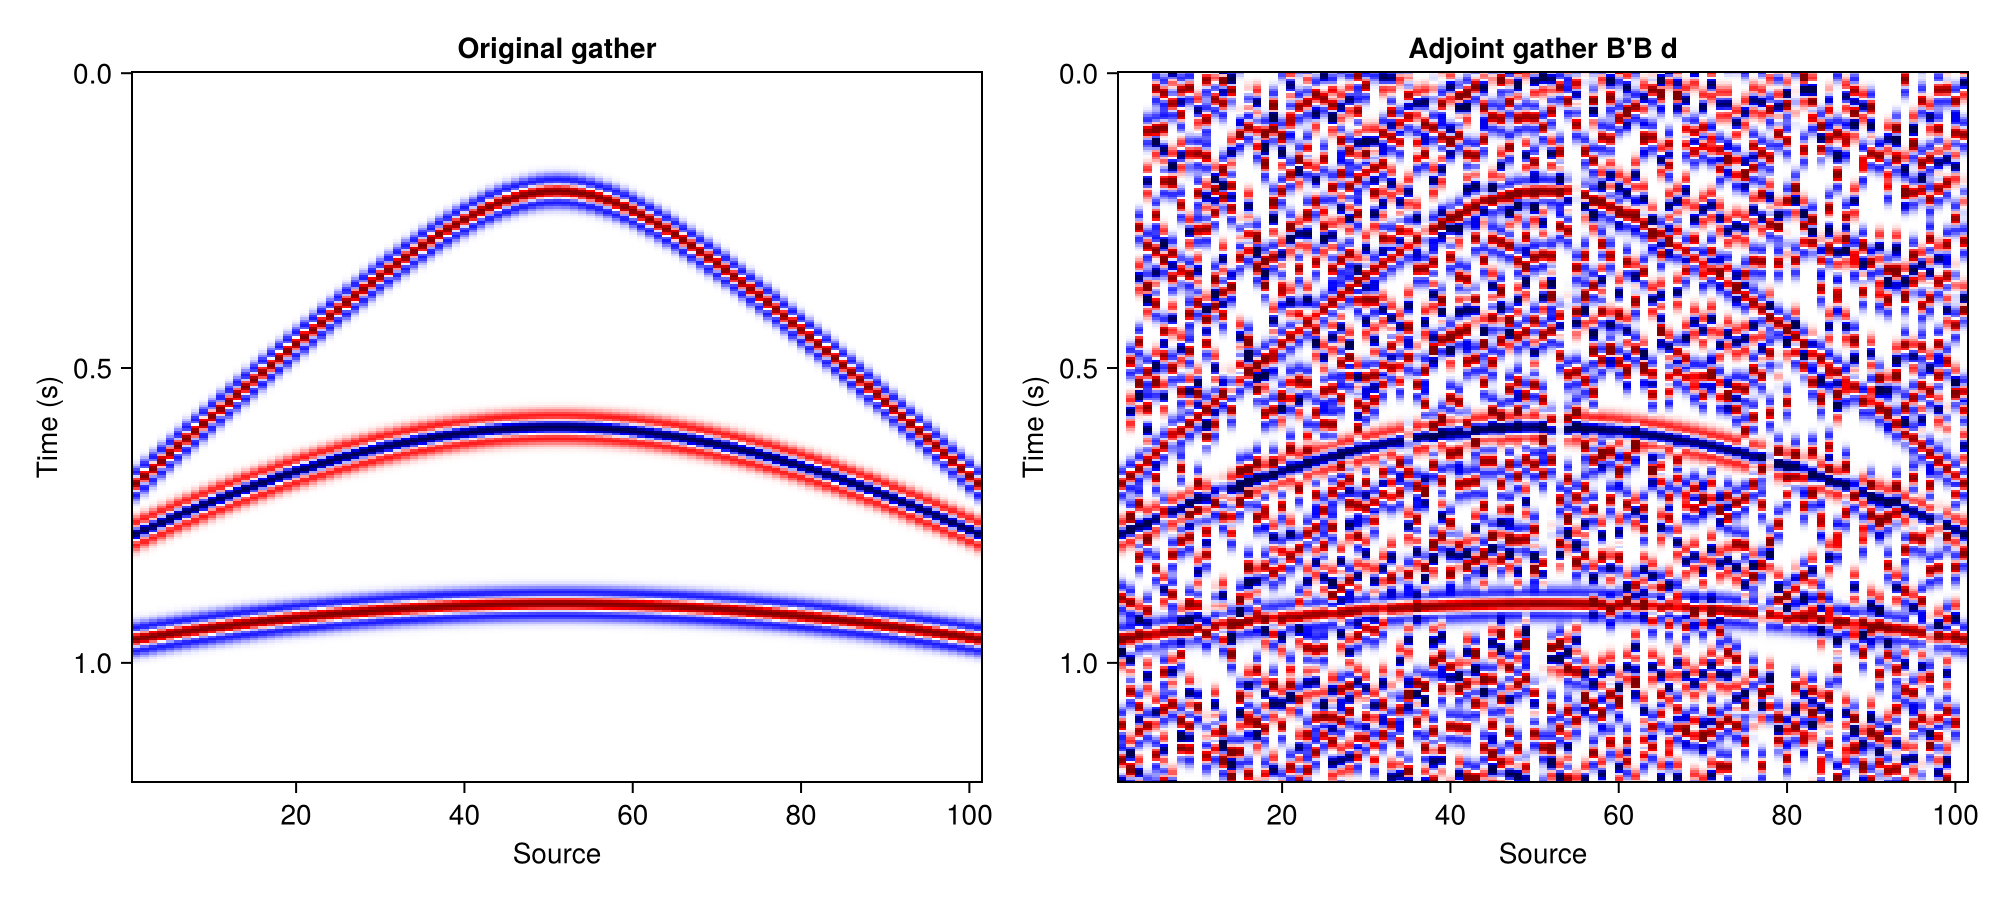

In [4]:
t = (0:nt-1) .* dt
lim = maximum(abs.(d))

fig = Figure(size=(1000,450))
ax1 = Axis(fig[1,1], xlabel="Source", ylabel="Time (s)", title="Original gather", yreversed=true)
heatmap!(ax1, 1:ns, t, d'; colormap=:seismic, colorrange=(-lim,lim))

ax2 = Axis(fig[1,2], xlabel="Source", ylabel="Time (s)", title="Adjoint gather B'B d", yreversed=true)
heatmap!(ax2, 1:ns, t, dadj'; colormap=:seismic, colorrange=(-lim,lim))
fig